# Area-average Precipitation

In [5]:
from pyenspp.utils import conform_obs, conform_forecast, area_mean_precip
import geopandas as gpd
from pathlib import Path
import xarray as xr
import os

current_dir = Path().resolve()  # get current directory
parent_dir = current_dir

# To get the path of the example data
data_path = parent_dir / "data"

obs_data_path = os.path.join(data_path, "example_obs.nc")
fcst_data_path = os.path.join(data_path,  "example_fcst.grib")
shp_path = os.path.join(data_path, "shp")

# Load and conform data
obs_ds = xr.open_dataset(obs_data_path)
obs_ds = conform_obs(obs_ds)

fcst_ds = xr.open_dataset(fcst_data_path)
fcst_ds = conform_forecast(fcst_ds)

# read shapefile
region = gpd.read_file(shp_path)

obs_area = area_mean_precip(obs_ds, region, )
fcst_area = area_mean_precip(fcst_ds, region)

print(obs_area)
print(fcst_area)

Variable 'prec' renamed to 'prec' and retained only this variable
Variable 'tp' renamed to 'prec' and retained only this variable
<xarray.DataArray 'prec' (time: 1)> Size: 8B
array([1.08953736])
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-01-01
Attributes:
    long_name:   Area-weighted mean prec
    units:       mm/day
    method:      cos_lat_weighted
    region_crs:  EPSG:4326
    skipna:      True
<xarray.DataArray 'prec' (number: 10, time: 20, step: 47)> Size: 75kB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.71667313e+02, 1.71687412e+02, 1.78510676e+02],
        [0.00000000e+00, 8.36305532e-03, 8.36305532e-03, ...,
         6.84068405e+01, 6.91455501e+01, 6.96679912e+01],
        [0.00000000e+00, 4.52233340e-01, 7.20450538e+00, ...,
         9.99512399e+01, 1.00192431e+02, 1.04807258e+02],
        ...,
        [0.00000000e+00, 3.51737043e-02, 3.51737043e-02, ...,
         1.46693257e+02, 1.46693257e+02, 1.46693257e+02],
        [0.00000000e

# Convert accumulated precipitation to per-step

变量 'tp' 已重命名为 'prec' 并筛选，仅保留该变量
[ 0.          0.20997697  3.57899906  3.72494684  3.7338246   5.09318623
  7.27455687  8.23685809 14.11593829 17.85832666]
[0.         0.20997697 3.36902209 0.14633841 0.00915652 1.35936164
 2.18137064 0.9628037  5.8790802  3.74238837]


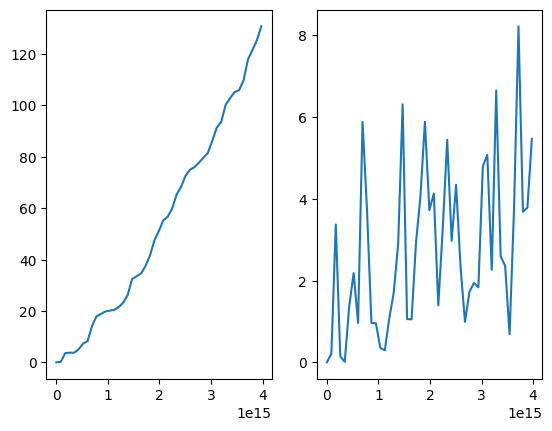

In [8]:
from pywepp.utils import conform_obs, conform_forecast, cum_to_step, area_mean_precip
import geopandas as gpd
from pathlib import Path
import xarray as xr
import os
import matplotlib.pyplot as plt

current_dir = Path().resolve()  # get current directory
parent_dir = current_dir

# get the path of the example data
data_path = parent_dir / "data"
# get the mean precipitation of the ens_forecast
fcst_data_path = os.path.join(data_path,  "example_fcst.grib")
fcst_ds = xr.open_dataset(fcst_data_path)
fcst_ds = conform_forecast(fcst_ds)

shp_path = os.path.join(data_path, "shp")
region = gpd.read_file(shp_path)
fcst_area = area_mean_precip(fcst_ds, region)

# convert the cum_prec to step_prec
fcst_area_step = cum_to_step(fcst_area, var_name='prec')

fig, axes = plt.subplots(nrows=1, ncols=2)
time = '2024-01-01'
axes[0].plot(fcst_area.step, fcst_area.sel(time=time).mean(dim='number'))
axes[1].plot(fcst_area_step.step, fcst_area_step.sel(time=time).mean(dim='number'))
print(fcst_area.sel(time=time).mean(dim='number').values[:10])
print(fcst_area_step.sel(time=time).mean(dim='number').values[:10])